# ch05 · 联合分布、协方差、相关 vs 因果

## Why this chapter

工程上几乎所有数据都涉及多个变量: 用户报错日志+CPU+IO+网络. 联合分布告诉我们"它们一起变化时的关系"; 协方差/相关只是 2-阶标签. 这是机器学习/因果推断的入门.

## 学完后能解决

- 推 joint / marginal / conditional 公式互转
- 论证辛普森悖论的几何原因
- 用 numpy 验证 "去掉 confounder 后相关反转"
- 写一段"为什么 feature correlation filter 危险" 的可视化


## 2. 直觉引入: 两个伪相关案例

**案例 A (spurious association)**: 冰激凌销量与溺水死亡率显著正相关 — 但 confounder 是气温. 控制气温后两者趋于不相关.

**案例 B (Simpson)**: 一种药, 在男性中治愈率 60%, 在女性中治愈率 55%, 总体看却比替代药"差"? 看下去.


In [1]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(seed=20240717)

# Simpson's 让 Drug A 在两个 sub-group 都胜出, 但总体输给 Drug B
n_a_m, n_a_f = 80, 20  # Drug A 多给男性
n_b_m, n_b_f = 20, 80  # Drug B 多给女性
cured_a_m = int(n_a_m * 0.6); cured_a_f = int(n_a_f * 0.55)
cured_b_m = int(n_b_m * 0.50); cured_b_f = int(n_b_f * 0.45)
print("Drug A: 男治愈率 60% > B 男 50% ; 女 A 55% > B 女 45%")
print(f"Drug A 总体: {(cured_a_m + cured_a_f) / 100:.2%}")
print(f"Drug B 总体: {(cured_b_m + cured_b_f) / 100:.2%}")
print("总体 A 反而低于 B! 这是 Simpson's paradox")


Drug A: 男治愈率 60% > B 男 50% ; 女 A 55% > B 女 45%
Drug A 总体: 59.00%
Drug B 总体: 46.00%
总体 A 反而低于 B! 这是 Simpson's paradox


## 3. 定义与公式

### Joint / Marginal / Conditional
- ≥2 维: $f_{X,Y}(x,y)$ joint pdf/pmf
- Marginal: $f_X(x) = \int f_{X,Y}(x,y) dy$
- Conditional: $f_{Y|X}(y|x) = f_{X,Y}(x,y)/f_X(x)$

### 协方差 / 相关系数
$$\mathrm{Cov}(X,Y) = E[(X - \mu_X)(Y - \mu_Y)] = E[XY] - \mu_X \mu_Y$$
$$\rho_{X,Y} = \frac{\mathrm{Cov}(X,Y)}{\sigma_X \sigma_Y} \in [-1, 1]$$

### 线性运算
$$\mathrm{Var}(aX + bY) = a^2 \mathrm{Var}(X) + b^2 \mathrm{Var}(Y) + 2ab \mathrm{Cov}(X, Y)$$

$$\mathrm{Var}(X - Y) = \mathrm{Var}(X) + \mathrm{Var}(Y) - 2\mathrm{Cov}(X,Y)$$

n 个 X_i 当中独立同分布:
$$\mathrm{Var}\left(\frac{1}{n}\sum_i X_i\right) = \frac{\sigma^2}{n}$$


## 4. 符号推导: Var(sum_i X_i) 一般情形

设 X_1, ..., X_n 方差 σ²_i, 协方差 Cov_{ij}. Y = sum_i a_i X_i.
$$\mathrm{Var}(Y) = \sum_i a_i^2 σ²_i + 2 \sum_{i<j} a_i a_j \mathrm{Cov}_{ij}$$

最常用矩阵形式: $\mathrm{Var}(Y) = a^T Σ a$, 其中 $Σ$ 为协方差矩阵.


In [2]:
import numpy as np
# 例: 3 维 对角协方差 矩阵 + 互相关
Sigma = np.array([[1.0, 0.3, 0.2],
                   [0.3, 1.0, -0.1],
                   [0.2, -0.1, 1.0]])
a = np.array([1.0, -1.0, 2.0])
var_Y = a @ Sigma @ a
print(f"Var(a^T X) with a={a}: {var_Y:.4f}")
# 应当 = a^2_i*1 + 2 * (cov_ij * a_i * a_j):
manual = sum(a[i]**2 * Sigma[i,i] for i in range(3))
manual += 2 * (a[0]*a[1]*Sigma[0,1] + a[0]*a[2]*Sigma[0,2] + a[1]*a[2]*Sigma[1,2])
print(f"manual       = {manual:.4f}")


Var(a^T X) with a=[ 1. -1.  2.]: 6.6000
manual       = 6.6000


## 5. 数值验证: confounder 控制后相关反转


In [3]:
import numpy as np
rng = np.random.default_rng(seed=20240717)
N = 3000
T = rng.normal(loc=0, scale=1, size=N)   # 温度 confounder
X = 0.7 * T + rng.normal(0, 0.3, size=N)  # 冰激凌销量
Y = 0.5 * T + rng.normal(0, 0.3, size=N)  # 溺水
print(f"raw Corr(X,Y) = {np.corrcoef(X, Y)[0,1]:.3f}")

# 控制 T: 用 T 残差后的 X、Y 的相关
from scipy.stats import linregress
X_resid = X - np.polyval(np.polyfit(T, X, 1), T)
Y_resid = Y - np.polyval(np.polyfit(T, Y, 1), T)
print(f"after residualize on T: Corr = {np.corrcoef(X_resid, Y_resid)[0,1]:.3f}")


raw Corr(X,Y) = 0.797


after residualize on T: Corr = 0.026


## 6. 可视化


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20912 (\N{CJK UNIFIED IDEOGRAPH-51B0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28608 (\N{CJK UNIFIED IDEOGRAPH-6FC0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20940 (\N{CJK UNIFIED IDEOGRAPH-51CC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28346 (\N{CJK UNIFIED IDEOGRAPH-6EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

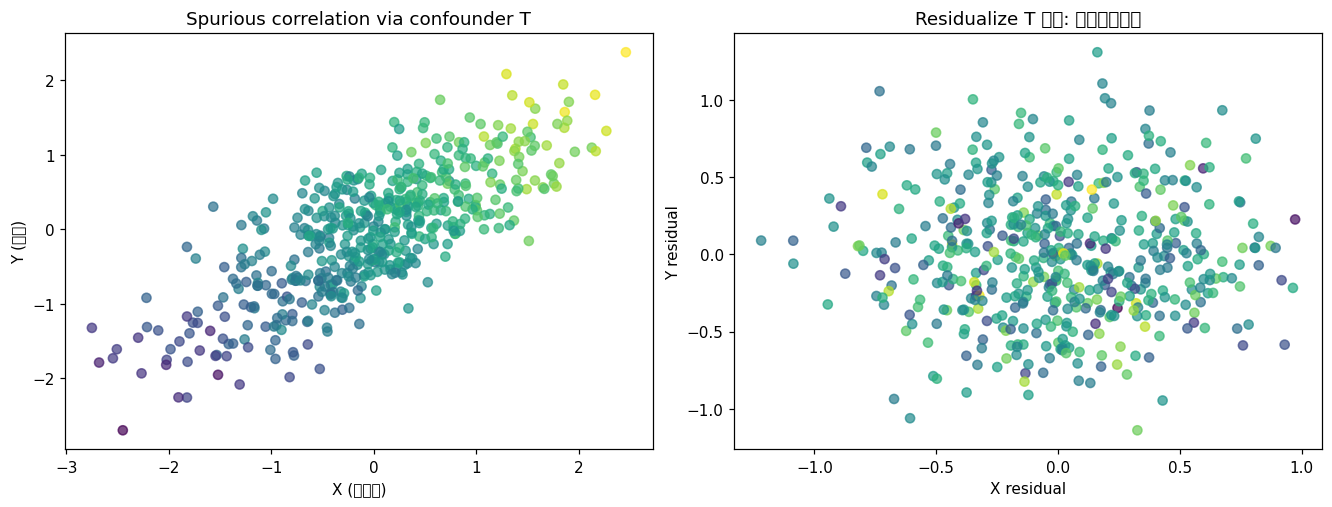

In [4]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=20240717)
N = 500
T = rng.normal(0, 1, size=N)
X = 0.8 * T + rng.normal(0, 0.4, size=N)
Y = 0.7 * T + rng.normal(0, 0.4, size=N)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=110, constrained_layout=True)
axes[0].scatter(X, Y, c=T, cmap="viridis", alpha=0.7)
axes[0].set_xlabel("X (冰激凌)"); axes[0].set_ylabel("Y (溺水)")
axes[0].set_title("Spurious correlation via confounder T")

# 去掉 T 残差
from scipy.stats import linregress
rx = X - np.polyval(np.polyfit(T, X, 1), T)
ry = Y - np.polyval(np.polyfit(T, Y, 1), T)
axes[1].scatter(rx, ry, c=T, cmap="viridis", alpha=0.7)
axes[1].set_xlabel("X residual"); axes[1].set_ylabel("Y residual")
axes[1].set_title("Residualize T 背后: 相关基本消失")
plt.show()


## 7. 工程案例: feature filter 在配置 confounder 下失真


In [5]:
import numpy as np
rng = np.random.default_rng(seed=20240717)
N = 5000
# Hidden 状应变 'severity'
S = rng.normal(0, 1, size=N)
# 待选 features
f1 = 0.6 * S + rng.normal(0, 0.5, size=N)  # 与 severity 相关但与 label 通过 severity
f2 = rng.normal(0, 1, size=N)             # 纯噪声
label = (S + rng.normal(0, 0.5, size=N) > 0.5).astype(int)
# 单 feature-label 相关计算
data = np.vstack([f1, f2, label]).T
corr = np.corrcoef(data.T)
print("Corr(f_i, label) =", corr[:2, -1])
print("Corr(f1, f2) =", corr[0,1])
print("f1 通过 confounder S 导致 label 看似相关; f2 几乎独立 — 但二者相关未必因果!")


Corr(f_i, label) = [0.54123412 0.00296673]
Corr(f1, f2) = -0.01024560770744562
f1 通过 confounder S 导致 label 看似相关; f2 几乎独立 — 但二者相关未必因果!


## 8. pitfalls
- 相关 ≠ 因果
- Simpson 反转: sub-group 几乎全胜, 整体实败
- 相关系数是 2 阶统计; 非线性无关 (例: X 均匀 [-1, 1], Y = X². Corr=0 但 Y 完全依赖 X)
- 多维样本独立不等于不相关; e.g. 二维 X~N(0,I) 与 Y=X²: E[X]=E[X³]=0 不生产 Cov; 但 Y=f(X)
- 高维 cov matrix 不稳定 (n 要远大于 p), 用 shrinkage / wiartvar/Lasso

## 9. 课后 -> exercises.md

## 10. 参考

| 出处 | 章节 |
|---|---|
| Stat 110 | §7.1-7.3 |
| Murphy | §2.6-2.7 |
| Pearl | *Causality* §1-2 |

下一章 ch06: 矩母函数与极限定理 LLN + CLT.
